# CESM2-LE & NSIDC Sea Ice Slowdown Figures

Builds the three figures from `x_old/figures/F1_FS1_FS2_siextent_slowdown.py` by loading
pre-computed data from:
- **`scripts/01_slowdown_nsidc_sie_sia.py`** → NSIDC thresholds + per-month event files
- **`scripts/02_cesm2le_slowdowns.py`** → CESM2-LE slowdown classification files
- **CESM2-LE metrics files** → raw ensemble SIE/SIA time series

**Toggle the variable and month in Cell 2 (Configuration).**

In [3]:
import sys
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/lhoffma2/git/slowdown_arctic_seaice")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
print('Imports OK')

Imports OK


## Configuration
Change `VARIABLE` and `MONTH` here to regenerate all figures for a different variable / month.

In [4]:
from configs import paths

# ─────────────────────────────────────────────────────────────────────────────
# TOGGLE THESE
# ─────────────────────────────────────────────────────────────────────────────
VARIABLE = 'sie'    # 'sie'  or  'sia'
MONTH    = 'SEP'    # 'JAN' | 'FEB' | 'MAR' | 'APR' | 'MAY' | 'JUN'
                    # 'JUL' | 'AUG' | 'SEP' | 'OCT' | 'NOV' | 'DEC'
ENO      = 6        # Ensemble member to highlight in Fig 1 panels (e,f)  [0-based]

# Optional: path to CNN schematic PNG for Figure 2 panel (a)
# Set to None to skip the PNG panel and show only the two data panels.
PNG_PATH = paths.DATA_ROOT / 'models/schematic/cnn_schematic.png'     # e.g. '/path/to/cnn_schematic.png'

# ─────────────────────────────────────────────────────────────────────────────
MONTH_LABELS = ['JAN','FEB','MAR','APR','MAY','JUN',
                'JUL','AUG','SEP','OCT','NOV','DEC']
MONTH_IDX  = MONTH_LABELS.index(MONTH)   # 0-based  (e.g. SEP → 8)
MONTH_NUM  = MONTH_IDX + 1               # 1-based  (e.g. SEP → 9)

VARNAME  = 'SIE' if VARIABLE == 'sie' else 'SIA'
VARLABEL = 'Sea Ice Extent' if VARIABLE == 'sie' else 'Sea Ice Area'
raw_prefix = 'siextentn' if VARIABLE == 'sie' else 'siarean'

print(f'Variable : {VARNAME}')
print(f'Month    : {MONTH}  (0-based index {MONTH_IDX})')
print(f'ENO      : {ENO}')

Variable : SIE
Month    : SEP  (0-based index 8)
ENO      : 6


## Paths

In [5]:
# Locate project root (notebook lives in notebooks/)
NOTEBOOKS_DIR = Path().resolve()
PROJECT_ROOT  = NOTEBOOKS_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))


# ── NSIDC ────────────────────────────────────────────────────────────────────
nsidc_thresholds_path = (
    paths.NSIDC_SIE_SLOWDOWN_THRESHOLDS if VARIABLE == 'sie'
    else paths.NSIDC_SIA_SLOWDOWN_THRESHOLDS
)
nsidc_events_path = (
    paths.nsidc_sie_slowdown_events(MONTH_NUM) if VARIABLE == 'sie'
    else paths.nsidc_sia_slowdown_events(MONTH_NUM)
)

# ── CESM2-LE slowdown classification files ───────────────────────────────────
cesm_slowdowns_dir = paths.CESM2LE_DIR / 'slowdowns'
cesm_slowdown_path = (
    cesm_slowdowns_dir
    / f'cesm2le_{VARIABLE}_slowdown_riles_{MONTH}_1990-2100.nc'
)

# ── CESM2-LE raw SIE / SIA metrics files (for time-series panels) ────────────
cesm_metrics_dir = paths.CESM2LE_AICE_DIR / 'metrics'

print('NSIDC thresholds :', nsidc_thresholds_path)
print('NSIDC events     :', nsidc_events_path)
print('CESM slowdowns   :', cesm_slowdown_path)
print('CESM metrics dir :', cesm_metrics_dir)

# Quick existence check
for p in [nsidc_thresholds_path, nsidc_events_path, cesm_slowdown_path]:
    status = '✓' if Path(p).exists() else '✗  NOT FOUND'
    print(f'  {status}  {Path(p).name}')

NSIDC thresholds : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/nsidc/nsidc_sie_slowdown_thresholds.nc
NSIDC events     : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/nsidc/nsidc_sie_slowdown_events_month09.nc
CESM slowdowns   : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/cesm2le/slowdowns/cesm2le_sie_slowdown_riles_SEP_1990-2100.nc
CESM metrics dir : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/cesm2le/aice/metrics
  ✓  nsidc_sie_slowdown_thresholds.nc
  ✓  nsidc_sie_slowdown_events_month09.nc
  ✓  cesm2le_sie_slowdown_riles_SEP_1990-2100.nc


## Load NSIDC data

In [6]:
# ── Thresholds (all 12 months in one file) ────────────────────────────────────
ds_thr = xr.open_dataset(nsidc_thresholds_path)
threshold_slowdown_all = ds_thr['threshold_slowdown'].values   # (12,)  M km² yr⁻¹
fraction_slowdown_all  = ds_thr['fraction_slowdown'].values    # (12,)  threshold / mean
ds_thr.close()

# For the selected month
thr_slow  = float(threshold_slowdown_all[MONTH_IDX])   # mean + std
frac_slow = float(fraction_slowdown_all[MONTH_IDX])    # threshold / mean

# Reconstruct mean and std of obs trends from threshold + fraction
# threshold = mean + std  and  fraction = threshold / mean
# → mean = threshold / fraction,  std = threshold - mean
mean_trend_obs = thr_slow / frac_slow
std_trend_obs  = thr_slow - mean_trend_obs

print(f'NSIDC {MONTH} threshold (slowdown) : {thr_slow:+.4f} M km² yr⁻¹')
print(f'  fraction  : {frac_slow:.4f}')
print(f'  mean trend: {mean_trend_obs:+.4f} M km² yr⁻¹')
print(f'  std  trend: {std_trend_obs:.4f} M km² yr⁻¹')

# ── Per-month events file (selected month) ────────────────────────────────────
ds_ev = xr.open_dataset(nsidc_events_path)

# Trend windows: starting year + slope + slowdown mask
nsidc_trend_years = ds_ev['year'].values.astype(int)         # (n_trends,)
nsidc_trends      = ds_ev['linear_trend'].values             # (n_trends,)
nsidc_slowdown    = ds_ev['slowdown'].values.astype(int)     # (n_trends,)  0/1

# Sea-ice time series starting from 1990
# Note: dim is 'yearsice'; 'yearice' is a separate non-dimension coordinate
nsidc_seaice       = ds_ev['seaice'].values                  # (n_years,)
nsidc_seaice_years = ds_ev.coords['yearice'].values.astype(int)  # (n_years,)

ds_ev.close()

print(f'\nNSIDC trend windows : {nsidc_trend_years[0]}–{nsidc_trend_years[-1]}'
      f'  (n={len(nsidc_trend_years)})')
print(f'NSIDC seaice years  : {nsidc_seaice_years[0]}–{nsidc_seaice_years[-1]}'
      f'  (n={len(nsidc_seaice_years)})')
print(f'Slowdown events     : {nsidc_slowdown.sum()} / {len(nsidc_slowdown)}')

NSIDC SEP threshold (slowdown) : -0.0119 M km² yr⁻¹
  fraction  : 0.1405
  mean trend: -0.0850 M km² yr⁻¹
  std  trend: 0.0730 M km² yr⁻¹

NSIDC trend windows : 1990–2015  (n=26)
NSIDC seaice years  : 1990–2025  (n=36)
Slowdown events     : 6 / 26


## Load CESM2-LE data

In [7]:
# ── CESM2-LE slowdown classification ─────────────────────────────────────────
ds_cesm = xr.open_dataset(cesm_slowdown_path)

trend_years             = ds_cesm['nyr'].values.astype(int)       # (n_trends,) e.g. 1990–2090
linear_trends_mean      = ds_cesm['linear_trends_mean'].values    # (n_trends,)
linear_trends_ens       = ds_cesm['linear_trends_ens'].values     # (nens, n_trends)
slowdown_ens            = ds_cesm['slowdown'].values.astype(int)  # (nens, n_trends)
threshold_slowdown_cesm = ds_cesm['threshold_slowdown'].values    # (n_trends,) = frac×mean_trend

ds_cesm.close()

n_ens        = linear_trends_ens.shape[0]
n_trends_cesm = linear_trends_mean.shape[0]

print(f'CESM trend windows: {trend_years[0]}–{trend_years[-1]}  (n={n_trends_cesm})')
print(f'Ensemble size     : {n_ens}')
print(f'Slowdowns total   : {slowdown_ens.sum()} / {slowdown_ens.size}'
      f'  ({100 * slowdown_ens.mean():.1f}%)')

# ── CESM2-LE raw SIE/SIA — for time-series panels ────────────────────────────
# Loads siextentn_{group}members_{MONTH}.nc  (or siarean_...)
# Files have dims (ensemble, time), shape ≈ (50, 111) for years 1990–2100
years90 = np.arange(1990, 2101)    # full 111-year time axis

ensemble_arrays = []
for group in ['first50', 'last50']:
    fpath = cesm_metrics_dir / f'{raw_prefix}_{group}members_{MONTH}.nc'
    if fpath.exists():
        ds_raw = xr.open_dataset(fpath)
        arr = ds_raw[raw_prefix].values.astype(np.float32)   # (n_group, nyear)
        ds_raw.close()
        ensemble_arrays.append(arr)
        print(f'  Loaded {fpath.name}  shape={arr.shape}')
    else:
        print(f'  WARNING: not found — {fpath.name}')

if ensemble_arrays:
    siei90       = np.concatenate(ensemble_arrays, axis=0)   # (100, 111)
    sie_ens_mean = np.nanmean(siei90, axis=0)                # (111,)
    print(f'\nCombined SIE shape : {siei90.shape}')
else:
    siei90 = sie_ens_mean = None
    print('WARNING: raw SIE not available — time-series panels will be skipped')

CESM trend windows: 1990–2090  (n=101)
Ensemble size     : 100
Slowdowns total   : 2599 / 10100  (25.7%)
  Loaded siextentn_first50members_SEP.nc  shape=(50, 111)
  Loaded siextentn_last50members_SEP.nc  shape=(50, 111)

Combined SIE shape : (100, 111)


## Derived quantities, styling & plot helpers

In [8]:
# ── Colours ───────────────────────────────────────────────────────────────────
COLOR_SLOWDOWN    = 'green'
COLOR_NO_SLOWDOWN = 'red'
COLOR_ENSEMBLE_BG = 'lightgray'
COLOR_MEAN        = 'black'
COLOR_MEMBER      = 'darkslateblue'
COLOR_THRESH_OBS  = 'steelblue'
COLOR_THRESH_MODEL = 'lightblue'

mpl.rcParams.update({
    'font.size'        : 18,
    'axes.titlesize'   : 20,
    'axes.labelsize'   : 20,
    'xtick.labelsize'  : 16,
    'ytick.labelsize'  : 16,
    'legend.fontsize'  : 16,
    'figure.titlesize' : 22,
    'lines.linewidth'  : 2.0,
    'axes.linewidth'   : 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size' : 6,
    'ytick.major.size' : 6,
})


# ── Axis-label helpers ────────────────────────────────────────────────────────
def ice_ylabel():
    return rf'{MONTH} {VARNAME} [M km$^2$]'

def trend_ylabel():
    return rf'decadal trend [M km$^2$ yr$^{{-1}}$]'


# ── Panel label ───────────────────────────────────────────────────────────────
def add_panel_label(ax, label, x=0.0, y=1.06, fontsize=20):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=fontsize, fontweight='bold',
            va='bottom', ha='left', clip_on=False)


# ── Coloured decadal-trend segment plotter ────────────────────────────────────
def plot_colored_decadal_segments(
    ax, years_window_start, series, slopes, slowdown_mask,
    window=10, lw=1.0,
    label_slowdown='decadal trend (yes, slowdown)',
    label_noslow='decadal trend (no slowdown)',
):
    """
    For each window j, plot the linear segment y = slope[j]*x + series[j]
    in green (slowdown) or red (no slowdown).
    """
    x = np.arange(window)
    first_slow = first_noslow = True
    for j in range(slopes.size):
        y0 = series[j]
        if not np.isfinite(y0) or not np.isfinite(slopes[j]):
            continue
        is_slow = bool(slowdown_mask[j] == 1)
        color   = COLOR_SLOWDOWN if is_slow else COLOR_NO_SLOWDOWN
        lab = ''
        if is_slow and first_slow:
            lab = label_slowdown;  first_slow = False
        elif (not is_slow) and first_noslow:
            lab = label_noslow;    first_noslow = False
        yr = years_window_start[j : j + window]
        ax.plot(yr, slopes[j] * x + y0, color=color, lw=lw, label=lab)


# ── Derived quantities from CESM2-LE ─────────────────────────────────────────
# Classify ensemble *mean* against the time-varying model threshold
# (threshold_slowdown_cesm = fraction_nsidc × linear_trends_mean, loaded from file)
model_slow_mask_mean   = (linear_trends_mean > threshold_slowdown_cesm).astype(int)

# Per-member trends: NaN where not a slowdown
linear_trends_slowdown = np.where(slowdown_ens == 1, linear_trends_ens, np.nan)

# SIE values at trend-window start years, NaN where member is *not* in slowdown
# Shape: (nens, n_trends_cesm)  — aligns siei90[:, :n_trends_cesm] with trend windows
if siei90 is not None:
    sie_for_trend_windows = siei90[:, :n_trends_cesm].copy()   # (nens, n_trends)
    sie_for_trend_windows[np.isnan(linear_trends_slowdown)] = np.nan
else:
    sie_for_trend_windows = None

print('Derived quantities ready.')

Derived quantities ready.


---
## Figure 1 — NSIDC and CESM2-LE SIE with decadal trends (6 panels)

| Panel | Content |
|-------|-----------------------------------|
| (a)   | NSIDC SIE time series + coloured decadal-trend segments |
| (b)   | NSIDC decadal trend time series coloured by slowdown |
| (c)   | CESM2-LE ensemble-mean SIE + coloured trend segments |
| (d)   | CESM2-LE ensemble-mean trend + obs & model thresholds |
| (e)   | All members (bg) + highlighted member with slowdown segments |
| (f)   | All member trends (bg) + mean + thresholds + highlighted member |

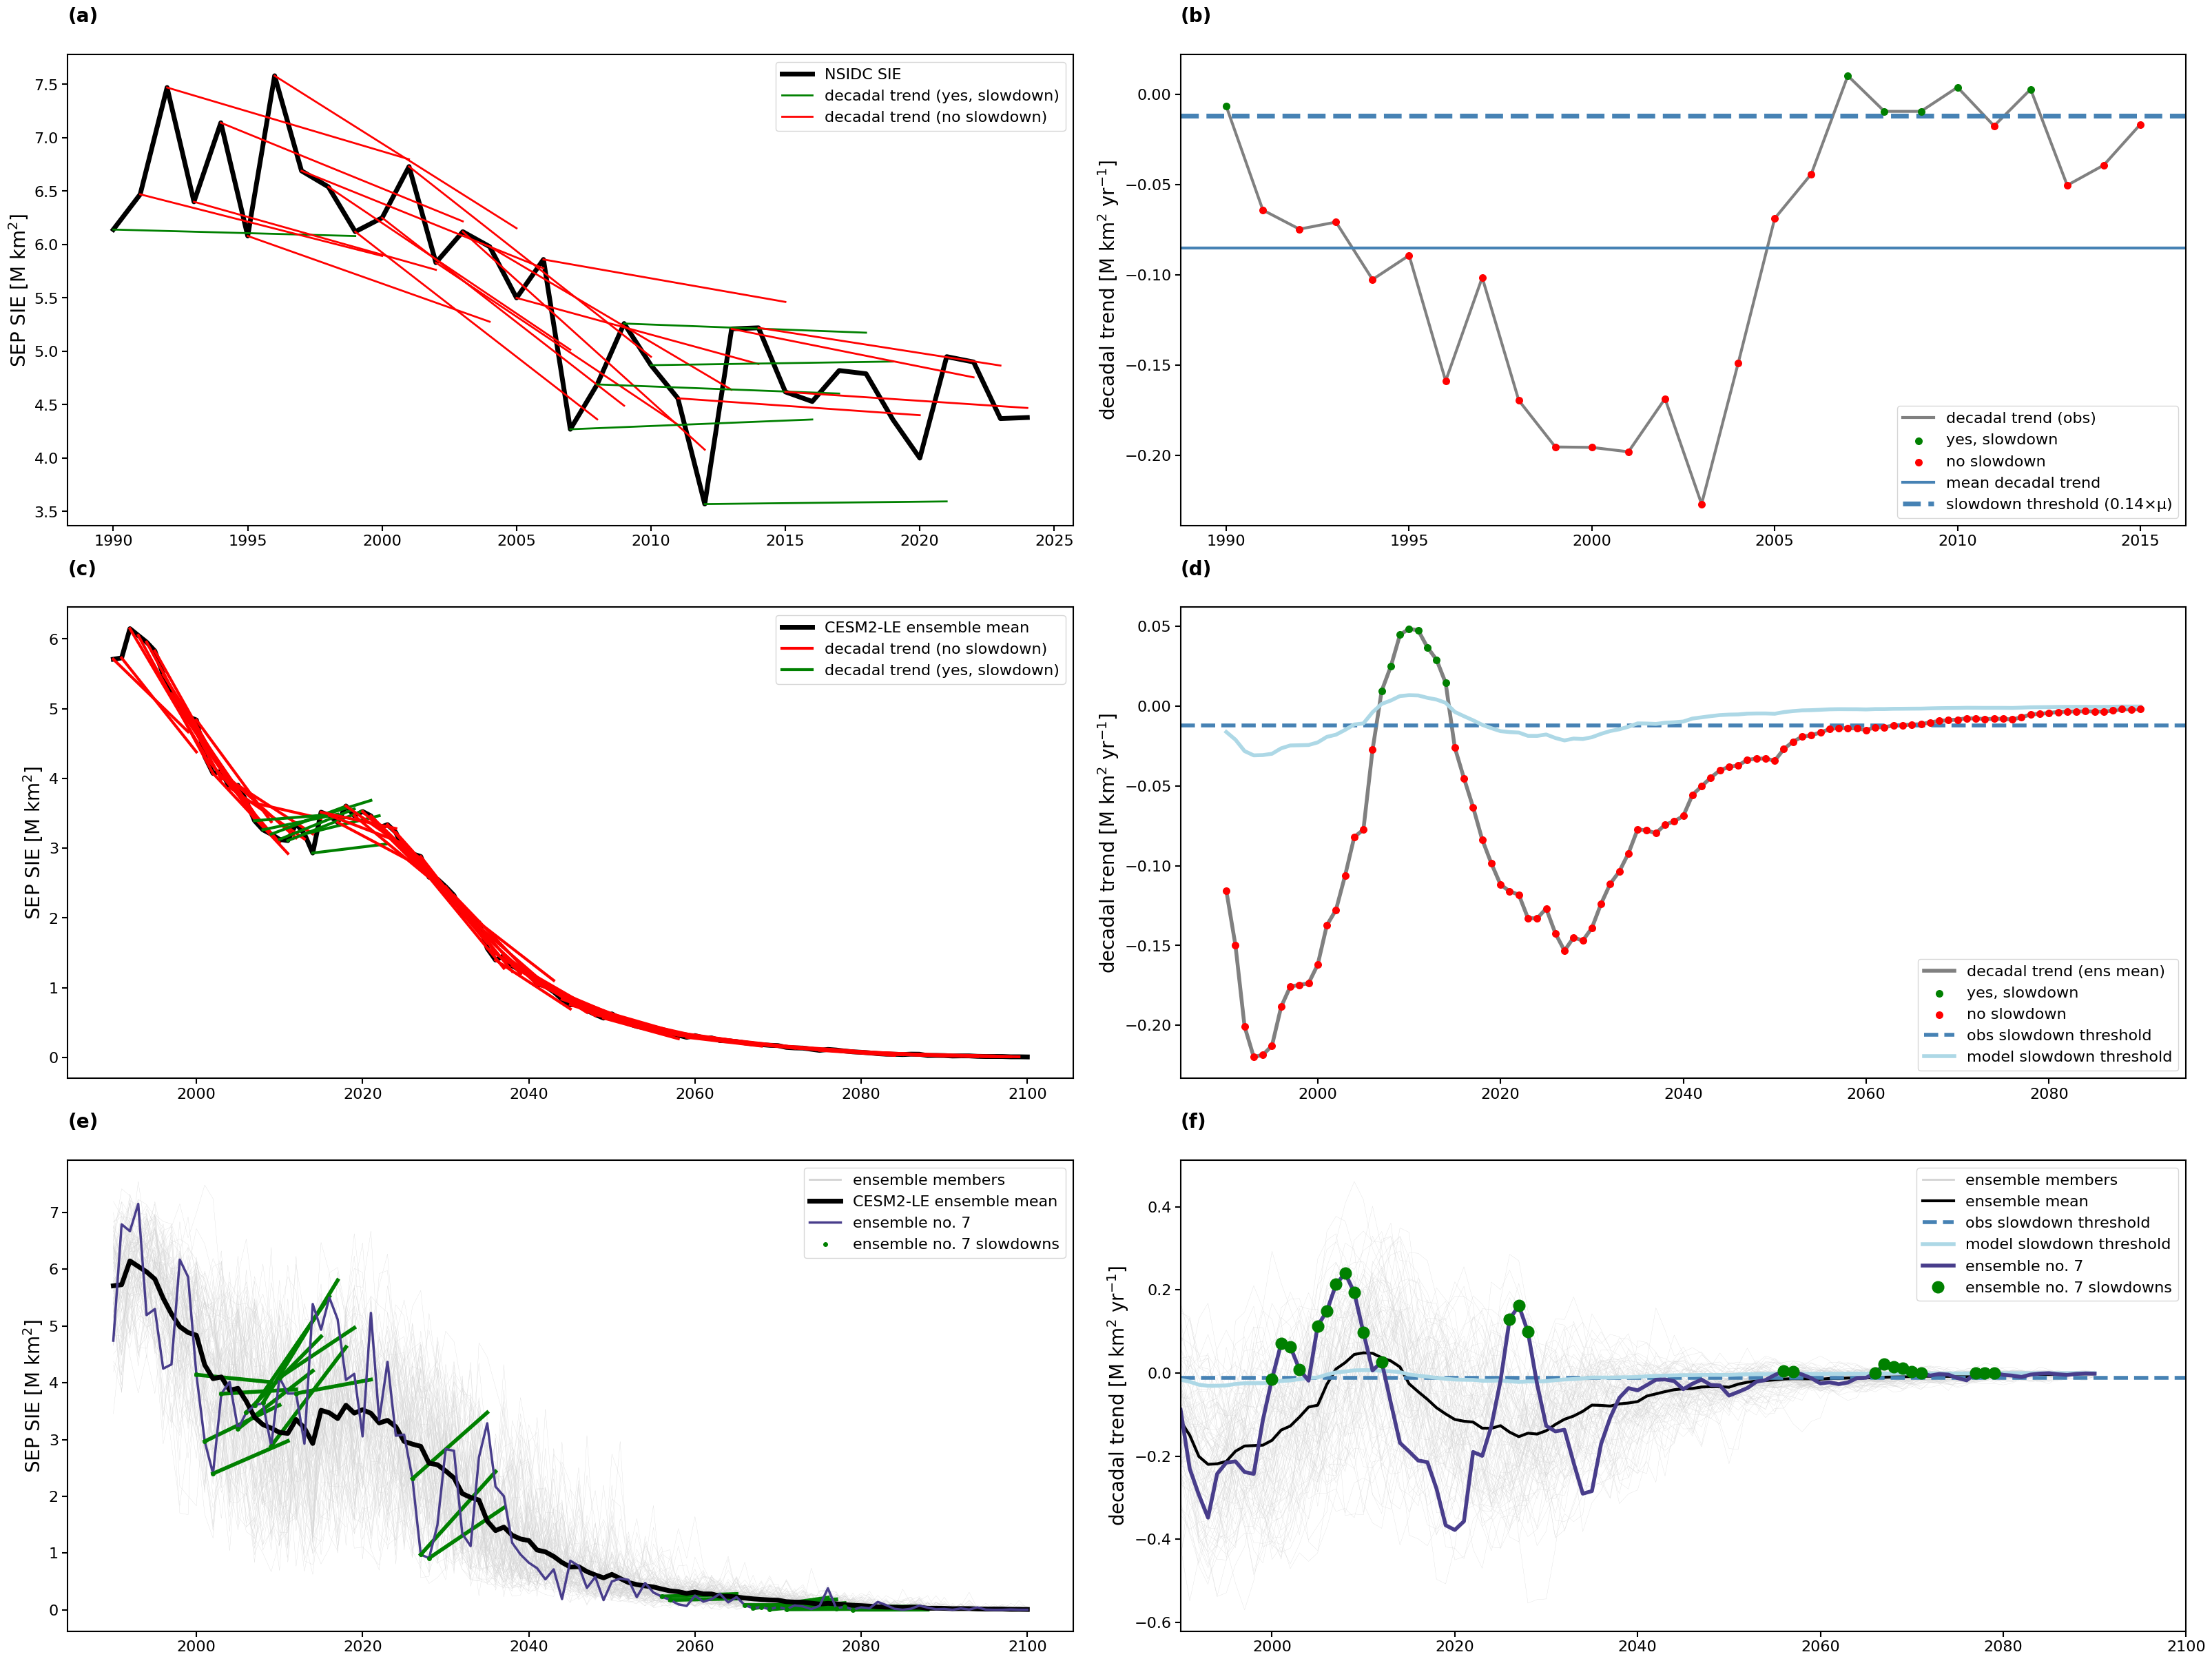

In [9]:
fig1, axes = plt.subplots(nrows=3, ncols=2, figsize=(32, 24), constrained_layout=True)
axa, axb = axes[0, 0], axes[0, 1]
axc, axd = axes[1, 0], axes[1, 1]
axe, axf = axes[2, 0], axes[2, 1]

# ── Panel (a): NSIDC SIE + coloured decadal-trend segments ───────────────────
axa.plot(nsidc_seaice_years, nsidc_seaice, lw=5, color='black',
         label=f'NSIDC {VARNAME}')
plot_colored_decadal_segments(
    axa,
    years_window_start=nsidc_seaice_years,   # starts at 1990
    series=nsidc_seaice,                      # starts at 1990
    slopes=nsidc_trends,
    slowdown_mask=nsidc_slowdown,
    window=10, lw=2.0,
    label_slowdown='decadal trend (yes, slowdown)',
    label_noslow='decadal trend (no slowdown)',
)
axa.set_ylabel(ice_ylabel())
add_panel_label(axa, '(a)')
axa.legend(loc='best')

# ── Panel (b): NSIDC trend time series coloured by slowdown ──────────────────
axb.plot(nsidc_trend_years, nsidc_trends, lw=3, color='gray',
         label='decadal trend (obs)')
axb.scatter(
    nsidc_trend_years[nsidc_slowdown == 1], nsidc_trends[nsidc_slowdown == 1],
    s=48, color=COLOR_SLOWDOWN, label='yes, slowdown', zorder=3,
)
axb.scatter(
    nsidc_trend_years[nsidc_slowdown == 0], nsidc_trends[nsidc_slowdown == 0],
    s=48, color=COLOR_NO_SLOWDOWN, label='no slowdown', zorder=3,
)
axb.axhline(mean_trend_obs, lw=3, color=COLOR_THRESH_OBS,
            label='mean decadal trend')
axb.axhline(thr_slow, lw=5, color=COLOR_THRESH_OBS, ls='--',
            label=f'slowdown threshold ({frac_slow:.2f}×μ)')
axb.set_ylabel(trend_ylabel())
add_panel_label(axb, '(b)')
axb.legend(loc='lower right')

# ── Panels (c)–(d): CESM2-LE ensemble mean ───────────────────────────────────
if siei90 is not None:
    # (c) ensemble-mean SIE + coloured trend segments
    axc.plot(years90, sie_ens_mean, lw=5, color='black',
             label='CESM2-LE ensemble mean')
    plot_colored_decadal_segments(
        axc,
        years_window_start=years90,
        series=sie_ens_mean,
        slopes=linear_trends_mean,
        slowdown_mask=model_slow_mask_mean,
        window=10, lw=3.0,
        label_slowdown='decadal trend (yes, slowdown)',
        label_noslow='decadal trend (no slowdown)',
    )
    axc.set_ylabel(ice_ylabel())
    add_panel_label(axc, '(c)')
    axc.legend(loc='best')
else:
    axc.text(0.5, 0.5, 'Raw SIE not available', transform=axc.transAxes,
             ha='center', va='center', fontsize=16)

# (d) ensemble-mean trend time series
axd.plot(trend_years, linear_trends_mean, lw=4, color='gray',
         label='decadal trend (ens mean)')
axd.scatter(
    trend_years[model_slow_mask_mean == 1], linear_trends_mean[model_slow_mask_mean == 1],
    s=48, color=COLOR_SLOWDOWN, label='yes, slowdown', zorder=3,
)
axd.scatter(
    trend_years[model_slow_mask_mean == 0], linear_trends_mean[model_slow_mask_mean == 0],
    s=48, color=COLOR_NO_SLOWDOWN, label='no slowdown', zorder=3,
)
axd.axhline(thr_slow, lw=4, color=COLOR_THRESH_OBS, ls='--',
            label='obs slowdown threshold')
axd.plot(trend_years, threshold_slowdown_cesm, lw=4, color=COLOR_THRESH_MODEL,
         label='model slowdown threshold')
axd.set_ylabel(trend_ylabel())
add_panel_label(axd, '(d)')
axd.legend(loc='best')

# ── Panels (e)–(f): all members + highlighted member ─────────────────────────
if siei90 is not None:
    # (e) all members as bg + ensemble mean + highlighted member
    for i in range(n_ens):
        axe.plot(years90, siei90[i, :], lw=0.2, color=COLOR_ENSEMBLE_BG)

    # Slowdown trend segments for highlighted member (ENO)
    for j in range(n_trends_cesm):
        if sie_for_trend_windows is not None and not np.isfinite(sie_for_trend_windows[ENO, j]):
            continue
        dx = np.arange(10)
        y0 = siei90[ENO, j]
        m  = linear_trends_ens[ENO, j]
        axe.plot(years90[j : j + 10], m * dx + y0, lw=4.0, color=COLOR_SLOWDOWN)

    axe.plot(years90, sie_ens_mean, lw=5, color=COLOR_MEAN,
             label='CESM2-LE ensemble mean')
    axe.plot(years90, siei90[ENO, :], lw=2.5, color=COLOR_MEMBER,
             label=f'ensemble no. {ENO + 1}')
    if sie_for_trend_windows is not None:
        axe.plot(trend_years, sie_for_trend_windows[ENO, :], lw=0, marker='o', ms=4,
                 color=COLOR_SLOWDOWN, label=f'ensemble no. {ENO + 1} slowdowns')
    axe.set_ylabel(ice_ylabel())
    add_panel_label(axe, '(e)')
    ens_handle = Line2D([], [], color=COLOR_ENSEMBLE_BG, lw=2, label='ensemble members')
    handles, labels = axe.get_legend_handles_labels()
    axe.legend(handles=[ens_handle] + handles, loc='best')
else:
    axe.text(0.5, 0.5, 'Raw SIE not available', transform=axe.transAxes,
             ha='center', va='center', fontsize=16)

# (f) all member trends as bg + mean + thresholds + highlighted member
for i in range(n_ens):
    axf.plot(trend_years, linear_trends_ens[i, :], lw=0.2, color=COLOR_ENSEMBLE_BG)

axf.plot(trend_years, linear_trends_mean, lw=3, color=COLOR_MEAN,
         label='ensemble mean')
axf.axhline(thr_slow, lw=4, color=COLOR_THRESH_OBS, ls='--',
            label='obs slowdown threshold')
axf.plot(trend_years, threshold_slowdown_cesm, lw=4, color=COLOR_THRESH_MODEL,
         label='model slowdown threshold')
axf.plot(trend_years, linear_trends_ens[ENO, :], lw=4, color=COLOR_MEMBER,
         label=f'ensemble no. {ENO + 1}')
axf.plot(trend_years, linear_trends_slowdown[ENO, :], lw=0, marker='o', ms=12,
         color=COLOR_SLOWDOWN, label=f'ensemble no. {ENO + 1} slowdowns')
axf.set_xlim([1990, 2100])
axf.set_ylabel(trend_ylabel())
add_panel_label(axf, '(f)')
ens_handle = Line2D([], [], color=COLOR_ENSEMBLE_BG, lw=2, label='ensemble members')
handles, labels = axf.get_legend_handles_labels()
axf.legend(handles=[ens_handle] + handles, loc='best')

#fig1.suptitle(f'Figure 1 — {MONTH} {VARNAME}', y=1.01)
plt.show()

---
## Figure 2 — Schematic + NSIDC + Ensemble member

- **Panel (a):** CNN schematic PNG (`PNG_PATH`; skipped if `None`)
- **Panel (b):** NSIDC SIE time series with coloured trend segments  *(same as Fig 1a)*
- **Panel (c):** CESM2-LE all-member background + highlighted member  *(same as Fig 1e)*

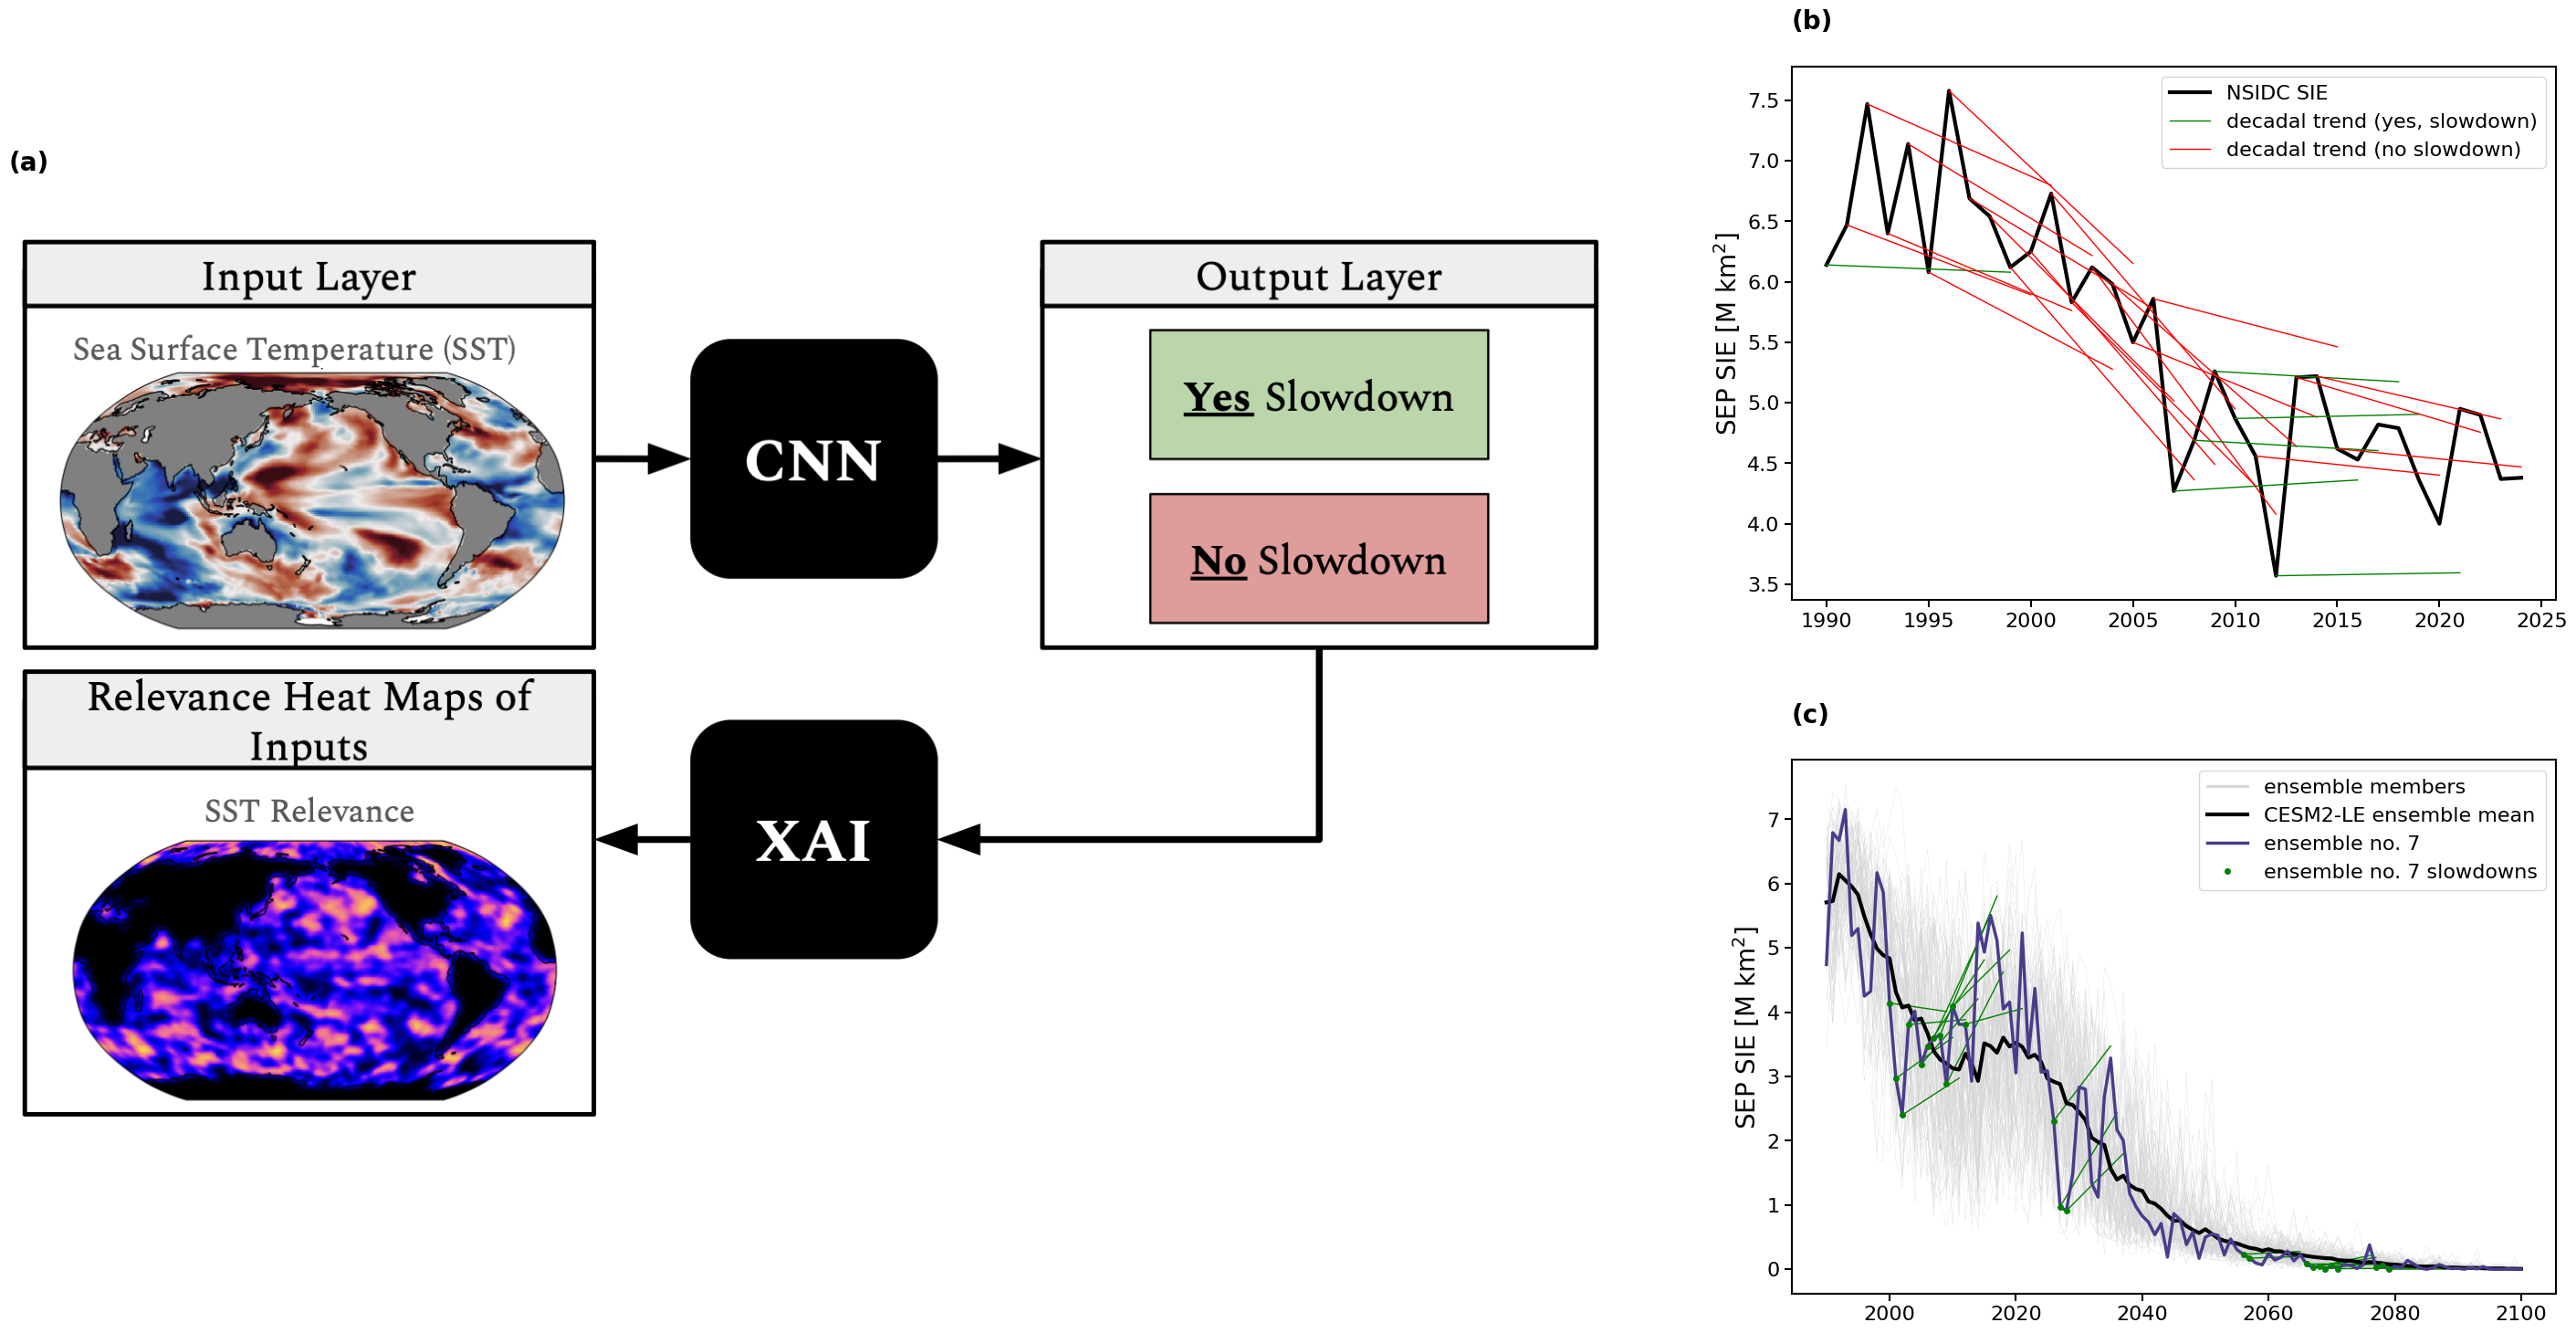

In [10]:
# Decide layout depending on whether a PNG path is provided
_png_available = PNG_PATH is not None and Path(PNG_PATH).exists()

if _png_available:
    from PIL import Image
    fig2 = plt.figure(figsize=(36, 16))
    gs = fig2.add_gridspec(nrows=2, ncols=2,
                           width_ratios=[2.1, 1.0],
                           wspace=0.15, hspace=0.30)
    ax_a = fig2.add_subplot(gs[:, 0])   # PNG — spans both rows
    ax_b = fig2.add_subplot(gs[0, 1])   # NSIDC (top right)
    ax_c = fig2.add_subplot(gs[1, 1])   # Ensemble (bottom right)

    img = Image.open(PNG_PATH)
    ax_a.imshow(img, aspect='auto')
    ax_a.axis('off')
    ax_a.set_box_aspect(img.size[1] / img.size[0])
    add_panel_label(ax_a, '(a)')
else:
    if PNG_PATH is not None:
        print(f'PNG not found at {PNG_PATH} — showing 2-panel layout')
    fig2, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(28, 10),
                                       constrained_layout=True)

# ── Panel (b): NSIDC SIE + coloured segments ─────────────────────────────────
ax_b.plot(nsidc_seaice_years, nsidc_seaice, lw=3, color='black',
          label=f'NSIDC {VARNAME}')
plot_colored_decadal_segments(
    ax_b,
    years_window_start=nsidc_seaice_years,
    series=nsidc_seaice,
    slopes=nsidc_trends,
    slowdown_mask=nsidc_slowdown,
    window=10, lw=1.0,
    label_slowdown='decadal trend (yes, slowdown)',
    label_noslow='decadal trend (no slowdown)',
)
ax_b.set_ylabel(ice_ylabel())
add_panel_label(ax_b, '(b)')
ax_b.legend(loc='best')

# ── Panel (c): All ensemble members + highlighted member ─────────────────────
if siei90 is not None:
    for i in range(n_ens):
        ax_c.plot(years90, siei90[i, :], lw=0.2, color=COLOR_ENSEMBLE_BG)

    for j in range(n_trends_cesm):
        if sie_for_trend_windows is not None and not np.isfinite(sie_for_trend_windows[ENO, j]):
            continue
        dx = np.arange(10)
        y0 = siei90[ENO, j]
        m  = linear_trends_ens[ENO, j]
        ax_c.plot(years90[j : j + 10], m * dx + y0, lw=1.0, color=COLOR_SLOWDOWN)

    ax_c.plot(years90, sie_ens_mean, lw=3, color=COLOR_MEAN,
              label='CESM2-LE ensemble mean')
    ax_c.plot(years90, siei90[ENO, :], lw=2.5, color=COLOR_MEMBER,
              label=f'ensemble no. {ENO + 1}')
    if sie_for_trend_windows is not None:
        ax_c.plot(trend_years, sie_for_trend_windows[ENO, :], lw=0, marker='o', ms=4,
                  color=COLOR_SLOWDOWN, label=f'ensemble no. {ENO + 1} slowdowns')
    ens_handle = Line2D([], [], color=COLOR_ENSEMBLE_BG, lw=2, label='ensemble members')
    handles, labels = ax_c.get_legend_handles_labels()
    ax_c.legend(handles=[ens_handle] + handles, loc='best')
else:
    ax_c.text(0.5, 0.5, 'Raw SIE not available', transform=ax_c.transAxes,
              ha='center', va='center', fontsize=16)

ax_c.set_ylabel(ice_ylabel())
add_panel_label(ax_c, '(c)')

#fig2.suptitle(f'Figure 2 — {MONTH} {VARNAME}', y=1.01)
if _png_available:
    fig2.subplots_adjust(top=0.95)
plt.show()

---
## Figure 3 — PDF / distribution of slowdown events (8 panels)

**Left column (a–d):** combined 1990–2090  
**Right column (e–h):** split 1990–2039 vs 2040–2090

| Panel | Content |
|-------|─────────|
| (a)   | Histogram of slowdown events per member (all years combined) |
| (b)   | Fraction of trend windows classified as slowdown vs normal |
| (c)   | PDF of SIE values during slowdown vs normal windows |
| (d)   | PDF of SIE anomalies during slowdown vs normal windows |
| (e–h) | Same as (a–d) but overlaying 1990–2039 and 2040–2090 subsets |


In [11]:
if siei90 is None:
    print('Raw SIE not available — Figure 3 requires siei90. Skipping.')
else:
    # SIE at each trend-window start: shape (nens, n_trends_cesm)
    sie_windows = siei90[:, :n_trends_cesm]   # (nens, n_trends_cesm)

    # Time subsets: 1990–2039  (indices 0:50)  and  2040–2090  (indices 50:)
    idx_split = int(np.where(trend_years == 2040)[0][0]) if 2040 in trend_years else 50
    subset_9039 = slice(0, idx_split)        # 1990–2039
    subset_4099 = slice(idx_split, None)     # 2040–2090

    # Switched: 4 rows × 2 columns (vertically tall)
    fig3, axes3 = plt.subplots(nrows=4, ncols=2, figsize=(24, 44),
                                constrained_layout=True)
    # Left column: all years combined
    axa3, axe3 = axes3[0, 0], axes3[0, 1]
    axb3, axf3 = axes3[1, 0], axes3[1, 1]
    axc3, axg3 = axes3[2, 0], axes3[2, 1]
    axd3, axh3 = axes3[3, 0], axes3[3, 1]

    # ── Left column: all years combined ───────────────────────────────────

    # (a) histogram of slowdown events per member
    slowdown_per_member = slowdown_ens.sum(axis=1)   # (nens,)
    max_val = int(slowdown_per_member.max())
    bins = np.arange(-1, max_val + 3)
    counts, edges = np.histogram(slowdown_per_member, bins=bins, density=True)
    axa3.bar(edges[:-1], counts, width=1.0, color=COLOR_THRESH_OBS,
             edgecolor='white', alpha=0.7)
    axa3.set_xlabel('Number of slowdown events per member')
    axa3.set_ylabel('Frequency')
    axa3.set_xticks(np.arange(0, max_val + 2, max(1, max_val // 10)))
    add_panel_label(axa3, '(a)')

    # (b) fraction slowdown vs normal (all events)
    flat = slowdown_ens.ravel()
    axb3.hist(flat, bins=[-0.5, 0.5, 1.5],
              weights=np.ones_like(flat) / len(flat), color='grey')
    axb3.set_xticks([0, 1])
    axb3.set_xticklabels(['no slowdown', 'slowdown'])
    axb3.set_ylabel('fraction of events')
    add_panel_label(axb3, '(b)')

    # (c) PDF of SIE during slowdown vs normal
    mask_all = slowdown_ens
    d0 = sie_windows[mask_all == 0]
    d1 = sie_windows[mask_all == 1]
    axc3.hist(d0, bins=30, alpha=0.6, density=True, color=COLOR_NO_SLOWDOWN,
              label='no slowdown')
    axc3.hist(d1, bins=30, alpha=0.6, density=True, color=COLOR_SLOWDOWN,
              label='slowdown')
    axc3.set_xlabel(rf'{MONTH} {VARNAME} [M km$^2$]')
    axc3.set_ylabel('Density')
    axc3.legend()
    add_panel_label(axc3, '(c)')

    # (d) PDF of SIE anomalies during slowdown vs normal
    sie_anom = sie_windows - np.nanmean(sie_windows, axis=0)
    d0a = sie_anom[mask_all == 0]
    d1a = sie_anom[mask_all == 1]
    axd3.hist(d0a, bins=30, alpha=0.6, density=True, color=COLOR_NO_SLOWDOWN,
              label='no slowdown')
    axd3.hist(d1a, bins=30, alpha=0.6, density=True, color=COLOR_SLOWDOWN,
              label='slowdown')
    axd3.set_xlabel(rf'{MONTH} {VARNAME} anomaly [M km$^2$]')
    axd3.set_ylabel('Density')
    axd3.legend()
    add_panel_label(axd3, '(d)')

    # ── Right column: split 1990–2039 / 2040–2090 ─────────────────────────
    slow_9039 = slowdown_ens[:, subset_9039]
    slow_4099 = slowdown_ens[:, subset_4099]
    sie_win_9039 = sie_windows[:, subset_9039]
    sie_win_4099 = sie_windows[:, subset_4099]

    yr_start_9039 = trend_years[subset_9039][0]
    yr_end_9039   = trend_years[subset_9039][-1]
    yr_start_4099 = trend_years[subset_4099][0]
    yr_end_4099   = trend_years[subset_4099][-1]

    # (e) histogram per member — overlay both periods
    spm_9039 = slow_9039.sum(axis=1)
    spm_4099 = slow_4099.sum(axis=1)
    max_val2 = int(np.concatenate([spm_9039, spm_4099]).max())
    bins2 = np.arange(-1, max_val2 + 3)

    cnts9039, edg9039 = np.histogram(spm_9039, bins=bins2, density=True)
    cnts4099, edg4099 = np.histogram(spm_4099, bins=bins2, density=True)
    axe3.bar(edg9039[:-1], cnts9039, width=1.0, color=COLOR_THRESH_OBS,
             edgecolor='white', alpha=0.7,
             label=f'{yr_start_9039}–{yr_end_9039}')
    axe3.bar(edg4099[:-1], cnts4099, width=1.0, color='red',
             edgecolor='white', alpha=0.2,
             label=f'{yr_start_4099}–{yr_end_4099}')
    axe3.set_xlabel('Number of slowdown events per member')
    axe3.set_ylabel('Frequency')
    axe3.set_xticks(np.arange(0, max_val2 + 2, max(1, max_val2 // 8)))
    axe3.legend()
    add_panel_label(axe3, '(e)')

    # (f) fraction slowdown vs normal (1990–2039 subset)
    flat_sub = slow_9039.ravel()
    axf3.hist(flat_sub, bins=[-0.5, 0.5, 1.5],
              weights=np.ones_like(flat_sub) / len(flat_sub), color='grey')
    axf3.set_xticks([0, 1])
    axf3.set_xticklabels(['no slowdown', 'slowdown'])
    axf3.set_ylabel('fraction of events')
    axf3.set_title(f'({yr_start_9039}–{yr_end_9039})', fontsize=16)
    add_panel_label(axf3, '(f)')

    # (g) PDF of SIE (1990–2039 subset)
    d0g = sie_win_9039[slow_9039 == 0]
    d1g = sie_win_9039[slow_9039 == 1]
    axg3.hist(d0g, bins=30, alpha=0.6, density=True, color=COLOR_NO_SLOWDOWN,
              label='no slowdown')
    axg3.hist(d1g, bins=30, alpha=0.6, density=True, color=COLOR_SLOWDOWN,
              label='slowdown')
    axg3.set_xlabel(rf'{MONTH} {VARNAME} [M km$^2$]')
    axg3.set_ylabel('Density')
    axg3.set_title(f'({yr_start_9039}–{yr_end_9039})', fontsize=16)
    axg3.legend()
    add_panel_label(axg3, '(g)')

    # (h) PDF of SIE anomalies (1990–2039 subset)
    anom_sub = sie_win_9039 - np.nanmean(sie_win_9039, axis=0)
    d0h = anom_sub[slow_9039 == 0]
    d1h = anom_sub[slow_9039 == 1]
    axh3.hist(d0h, bins=30, alpha=0.6, density=True, color=COLOR_NO_SLOWDOWN,
              label='no slowdown')
    axh3.hist(d1h, bins=30, alpha=0.6, density=True, color=COLOR_SLOWDOWN,
              label='slowdown')
    axh3.set_xlabel(rf'{MONTH} {VARNAME} anomaly [M km$^2$]')
    axh3.set_ylabel('Density')
    axh3.set_title(f'({yr_start_9039}–{yr_end_9039})', fontsize=16)
    axh3.legend()
    add_panel_label(axh3, '(h)')

    plt.show()
